# Metrics comparison

Given a model, this notebooks gives **utility** metrics, **fairness** metrics and **cost** metrics.

Description of each metrics :

- **utility** metrics : accuracy - F1 - precision - recall
- **fairness** metrics : SDP (Statistical Parity Difference) - EOD (Equal Opportunity Difference)
- **cost** metrics : training time - time to accuracy

The idea is to have one plot for every metrics, with several curves on each graphs corresponding to different noises values, iid repartition.

We are going to have test on : 
- different non iid parameters 
- different noise parameters 
- with differents models

### Imports

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

plt.style.use("seaborn-v0_8")



### Paths / Utils

In [18]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')


def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None


def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


cwd = Path.cwd()
print(f"Current working directory: {cwd}")
base = cwd / 'runs'
print(f"Looking for runs in: {base}")

Current working directory: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation
Looking for runs in: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation\runs


## Utility metrics

### IID

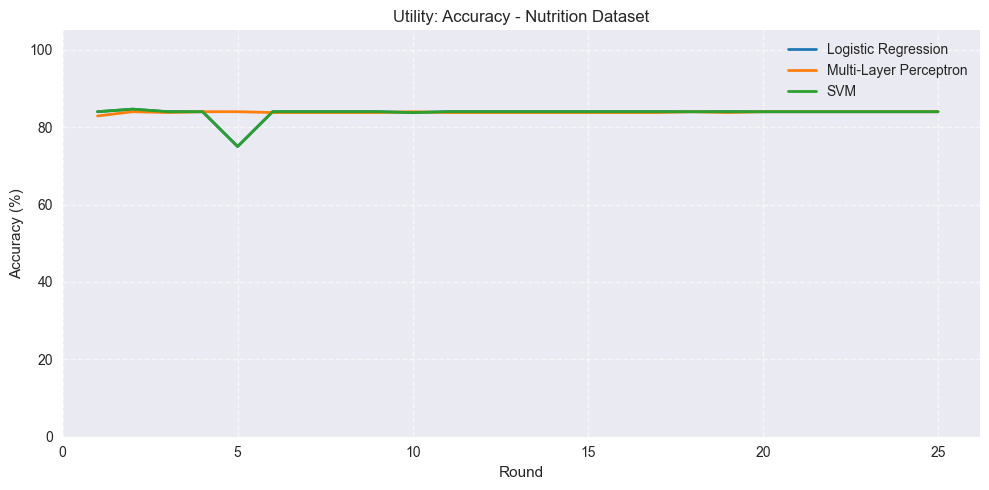

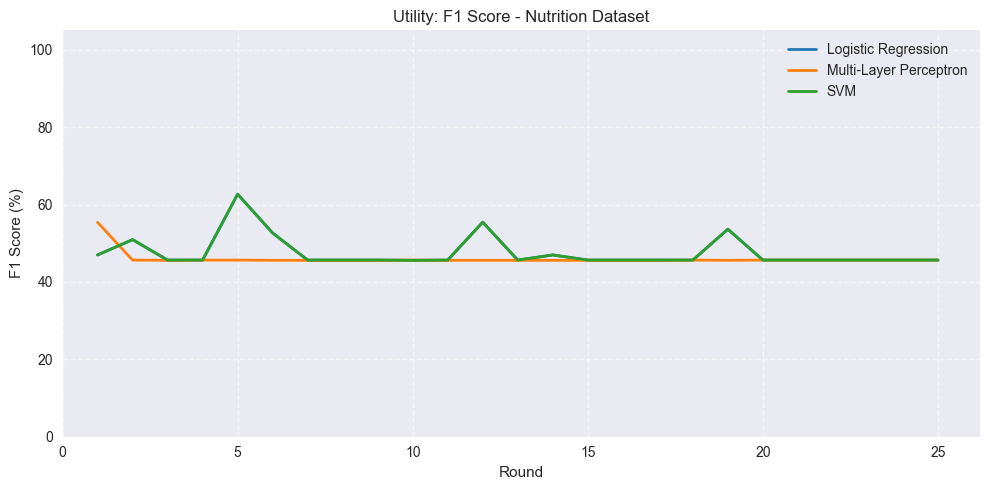

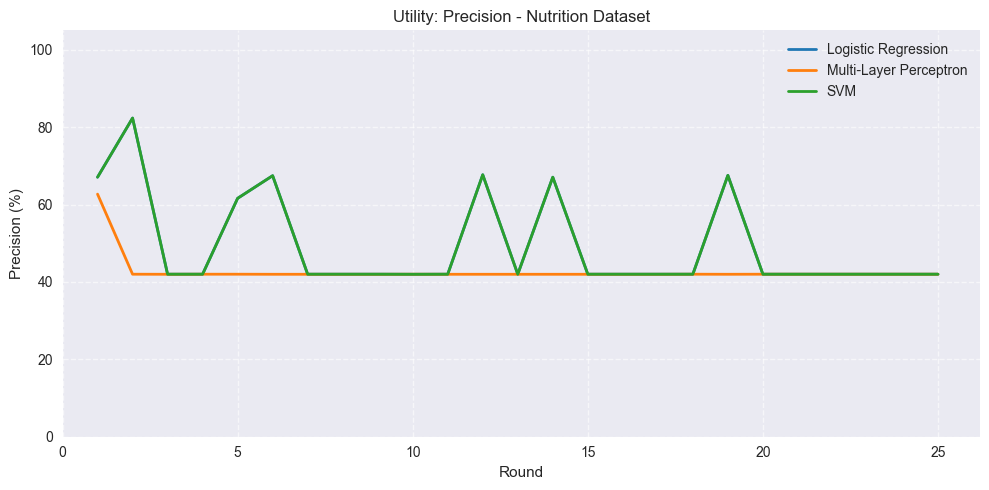

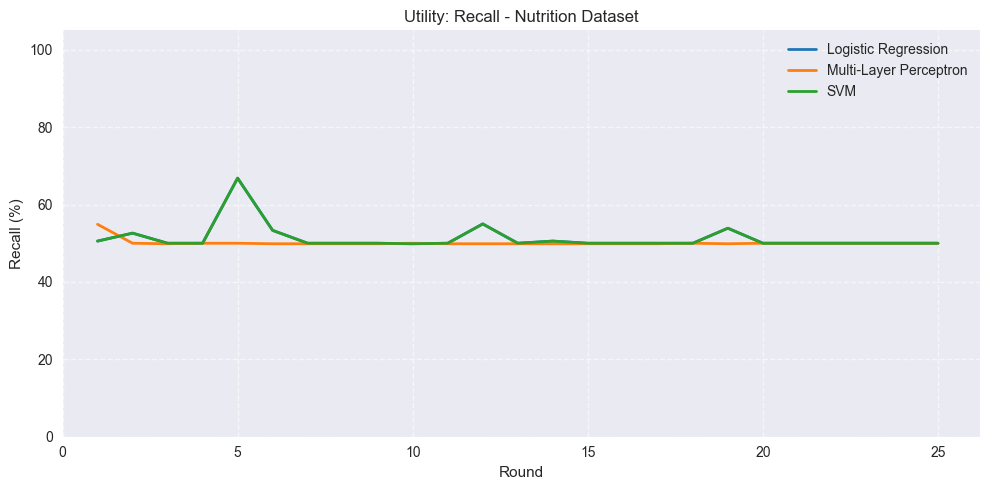

In [24]:
base = Path('runs') # ou ton chemin racine
iid_path = base / 'IID'
paths = {
    'LR': iid_path / 'LR',
    'MLP': iid_path / 'MLP',
    'SVM': iid_path / 'SVM',
}

metrics = {name: load_global_metrics(path) for name, path in paths.items()}

# Configuration visuelle
legend_map = {'LR': 'Logistic Regression', 'MLP': 'Multi-Layer Perceptron', 'SVM': 'SVM'}
color_map = {'LR': '#1f77b4', 'MLP': '#ff7f0e', 'SVM': '#2ca02c'}

# Liste des métriques à afficher : (Nom colonne CSV, Titre Axe Y, Titre Graphique)
plots_to_make = [
    ('accuracy', 'Accuracy (%)', 'Utility: Accuracy'),
    ('macro_f1', 'F1 Score (%)', 'Utility: F1 Score'),
    ('macro_precision', 'Precision (%)', 'Utility: Precision'),
    ('macro_recall', 'Recall (%)', 'Utility: Recall')
]

for col_name, y_label, title in plots_to_make:
    plt.figure(figsize=(10, 5))
    for name, df in metrics.items():
        if df.empty: continue
        
        # Gestion des variantes de noms de colonnes (ex: 'test_precision' vs 'precision')
        actual_col = col_name if col_name in df.columns else f'test_{col_name}'
        
        if actual_col in df.columns:
            plt.plot(
                df['round'],
                df[actual_col] * 100,
                label=legend_map.get(name, name),
                color=color_map.get(name),
                linewidth=2
            )
    
    plt.title(f'{title} - Nutrition Dataset')
    plt.xlabel('Round')
    plt.ylabel(y_label)
    plt.xlim(left=0)
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Non IID